# 02 - Feature engineering, training & experiment tracking
Runs the same code as `python -m heart.train`: three model families, grid-searched with stratified 5-fold CV, every run logged to MLflow.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import os
os.chdir(ROOT)

In [2]:
import json
import pandas as pd
from IPython.display import Image, display
from heart.features import build_preprocessor
from heart.data import load_clean, split_xy
from heart.models import candidate_models

## Preprocessing pipeline
One sklearn `Pipeline`: derived clinical features -> impute -> scale / one-hot. It is fitted inside every CV fold and saved together with the classifier, so serving gets identical transforms.

In [3]:
X, y = split_xy(load_clean())
prep = build_preprocessor().fit(X)
prep

Pipeline(steps=[('clinical', ClinicalFeatures()),
                ('columns',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak', 'ca',
                                                   'hr_reserve',
                                                   'chol_per_age']),
                                                 ('bin',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['sex', 'fbs', 'exang']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['cp', 'restecg', 'slope',
                                                   'thal'])]))])

In [4]:
pd.DataFrame(prep.transform(X)[:5], columns=prep.get_feature_names_out()).round(2)

,num__age,num__trestbps,num__chol,num__thalach,num__oldpeak,num__ca,num__hr_reserve,num__chol_per_age,bin__sex,bin__fbs,...,cat__cp_4.0,cat__restecg_0.0,cat__restecg_1.0,cat__restecg_2.0,cat__slope_1.0,cat__slope_2.0,cat__slope_3.0,cat__thal_3.0,cat__thal_6.0,cat__thal_7.0
0,0.95,0.76,-0.26,0.02,1.09,-0.71,0.41,-0.85,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1.39,1.61,0.76,-1.82,0.40,2.50,-1.54,-0.33,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
2,1.39,-0.67,-0.34,-0.90,1.35,1.43,-0.47,-1.10,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-1.93,-0.10,0.06,1.64,2.12,-0.71,0.93,1.93,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,-1.49,-0.10,-0.83,0.98,0.31,-0.71,0.45,0.31,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


## Search space

In [5]:
for name, (est, grid) in candidate_models().items():
    print(name, grid)

logistic_regression {'clf__C': [0.01, 0.1, 0.3, 1.0, 3.0], 'clf__class_weight': [None, 'balanced']}
random_forest {'clf__n_estimators': [200, 400], 'clf__max_depth': [None, 4, 8], 'clf__min_samples_leaf': [1, 3, 5]}
gradient_boosting {'clf__n_estimators': [100, 200], 'clf__learning_rate': [0.03, 0.1], 'clf__max_depth': [2, 3]}


## Train + track

In [6]:
from heart import train
best = train.main(folds=5)

2026/09/30 12:04:40 INFO mlflow.tracking.fluent: Experiment with name 'heart-disease-classification' does not exist. Creating a new experiment.


logistic_regression    cv_roc_auc=0.9079 test_roc_auc=0.9600 params={'clf__C': 0.3, 'clf__class_weight': 'balanced'}


random_forest          cv_roc_auc=0.8954 test_roc_auc=0.9556 params={'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 400}


gradient_boosting      cv_roc_auc=0.8811 test_roc_auc=0.9502 params={'clf__learning_rate': 0.03, 'clf__max_depth': 2, 'clf__n_estimators': 100}



Best model: logistic_regression (parent run 9d2e085ce7fa4ed4a61d1d5dacabe67d)
                     accuracy  precision  recall      f1  roc_auc
logistic_regression    0.8469     0.8794  0.7830  0.8238   0.9079
random_forest          0.8099     0.8253  0.7557  0.7829   0.8954
gradient_boosting      0.8097     0.8221  0.7648  0.7858   0.8811


Successfully registered model 'heart-disease-classifier'.
Created version '1' of model 'heart-disease-classifier'.


## Results

In [7]:
pd.read_csv('reports/figures/model_comparison.csv', index_col=0)

,accuracy,precision,recall,f1,roc_auc
logistic_regression,0.8469,0.8794,0.7830,0.8238,0.9079
random_forest,0.8099,0.8253,0.7557,0.7829,0.8954
gradient_boosting,0.8097,0.8221,0.7648,0.7858,0.8811


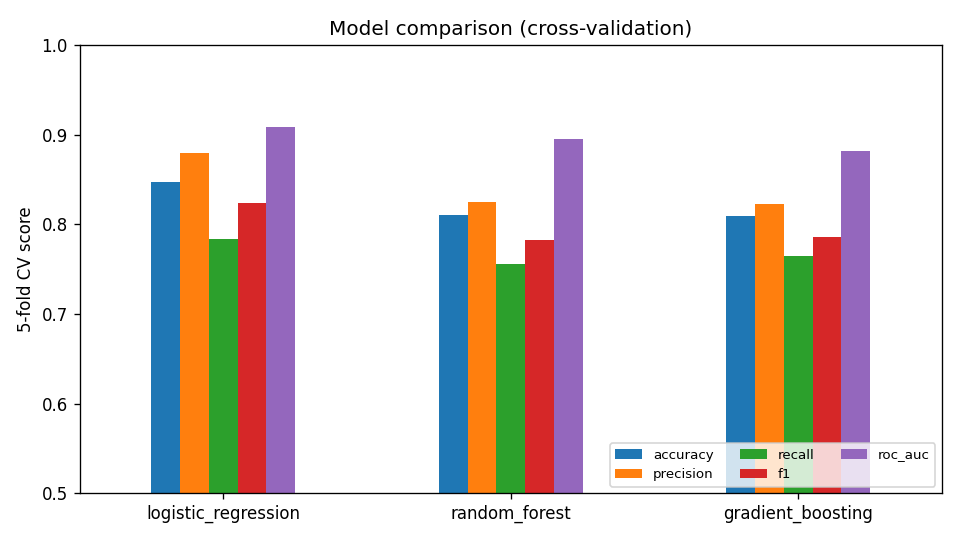

In [8]:
display(Image('reports/figures/model_comparison.png'))

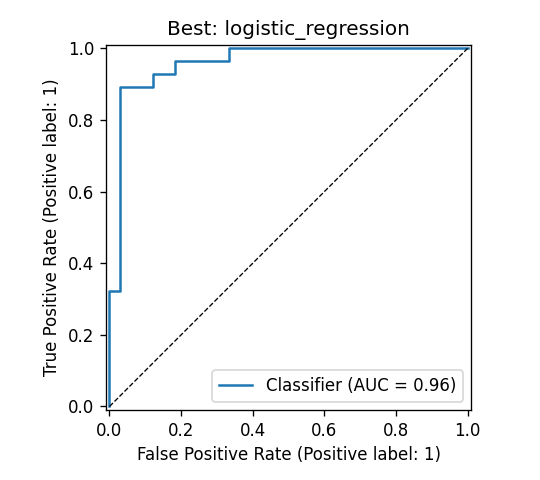

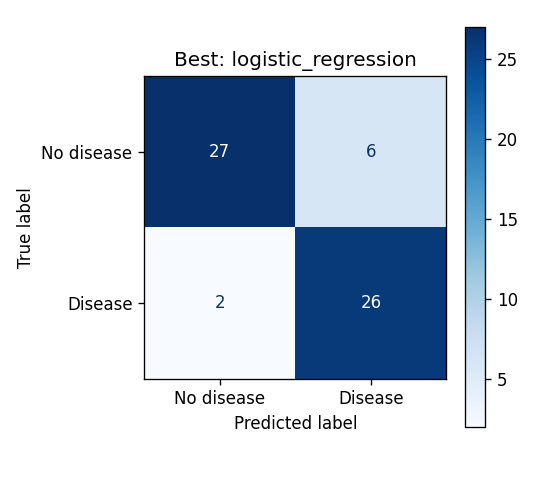

In [9]:
display(Image('reports/figures/best_roc_curve.png'), Image('reports/figures/best_confusion_matrix.png'))

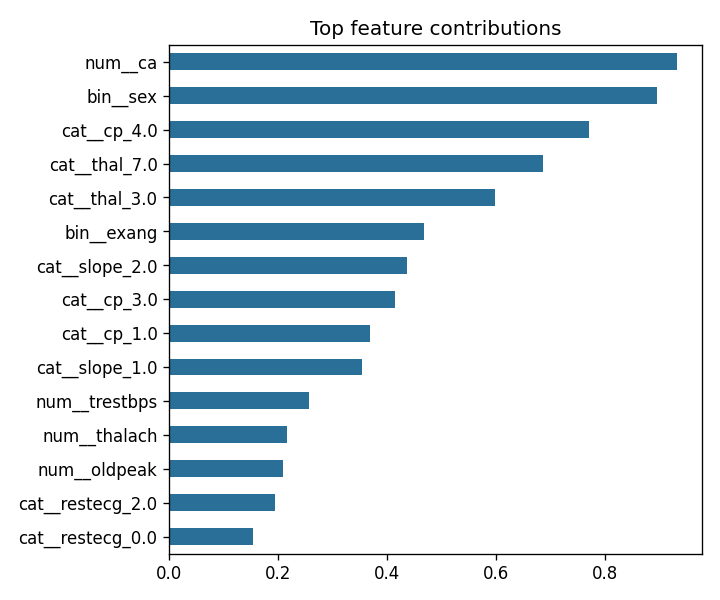

In [10]:
display(Image('reports/figures/best_feature_importance.png'))

In [11]:
print(json.dumps(json.load(open('models/metadata.json')), indent=2))

{
  "model_name": "logistic_regression",
  "mlflow_run_id": "bc8d168910c1438eac9fda7a689fa859",
  "best_params": {
    "C": 0.3,
    "class_weight": "balanced"
  },
  "cv_metrics": {
    "accuracy": 0.8469,
    "precision": 0.8794,
    "recall": 0.783,
    "f1": 0.8238,
    "roc_auc": 0.9079
  },
  "test_metrics": {
    "accuracy": 0.8689,
    "precision": 0.8125,
    "recall": 0.9286,
    "f1": 0.8667,
    "roc_auc": 0.96
  },
  "features": [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "ca",
    "sex",
    "fbs",
    "exang",
    "cp",
    "restecg",
    "slope",
    "thal"
  ],
  "train_rows": 242,
  "test_rows": 61,
  "sklearn_version": "1.5.2",
  "python_version": "3.12.13",
  "trained_at": "2026-09-30T06:34:54+00:00"
}


## Browse runs
Start the UI with `mlflow ui --backend-store-uri ./mlruns --host 127.0.0.1 --port 5000`.

In [12]:
import mlflow
mlflow.set_tracking_uri((ROOT / 'mlruns').as_uri())
runs = mlflow.search_runs(experiment_names=['heart-disease-classification'])
cols = ['tags.mlflow.runName', 'metrics.cv_roc_auc', 'metrics.cv_accuracy', 'metrics.cv_recall', 'metrics.test_roc_auc', 'metrics.test_accuracy', 'start_time']
runs[cols].dropna(subset=['metrics.cv_roc_auc']).round(4)

,tags.mlflow.runName,metrics.cv_roc_auc,metrics.cv_accuracy,metrics.cv_recall,metrics.test_roc_auc,metrics.test_accuracy,start_time
0,gradient_boosting,0.8811,0.8097,0.7648,0.9502,0.8852,2026-09-30 06:34:51.900000+00:00
1,random_forest,0.8954,0.8099,0.7557,0.9556,0.8852,2026-09-30 06:34:46.548000+00:00
2,logistic_regression,0.9079,0.8469,0.7830,0.9600,0.8689,2026-09-30 06:34:40.855000+00:00
